# **Realizamos un EDA de los datos.**

**Cargamos librerias**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("../data/processed/Adidas_US_Sales_procesed.csv")

# Vista rápida de los primeros registros
df.head(3)

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store


**Traget: Total Sales** ( Ventas Totales)

In [3]:
df.shape

(9648, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Retailer          9648 non-null   str    
 1   Retailer ID       9648 non-null   int64  
 2   Invoice Date      9648 non-null   str    
 3   Region            9648 non-null   str    
 4   State             9648 non-null   str    
 5   City              9648 non-null   str    
 6   Product           9648 non-null   str    
 7   Price per Unit    9648 non-null   float64
 8   Units Sold        9648 non-null   int64  
 9   Total Sales       9648 non-null   float64
 10  Operating Profit  9648 non-null   float64
 11  Operating Margin  9648 non-null   float64
 12  Sales Method      9648 non-null   str    
dtypes: float64(4), int64(2), str(7)
memory usage: 1.6 MB


In [5]:
df.describe()

,Retailer ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.648000e+03,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,45.216625,256.930037,93273.437500,34425.244761,0.422991
std,2.636038e+04,14.705397,214.252030,141916.016727,54193.113713,0.097197
min,1.128299e+06,7.000000,0.000000,0.000000,0.000000,0.100000
25%,1.185732e+06,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,1.185732e+06,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,1.185732e+06,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,1.197831e+06,110.000000,1275.000000,825000.000000,390000.000000,0.800000


# **Analisis exploratorio de datos**

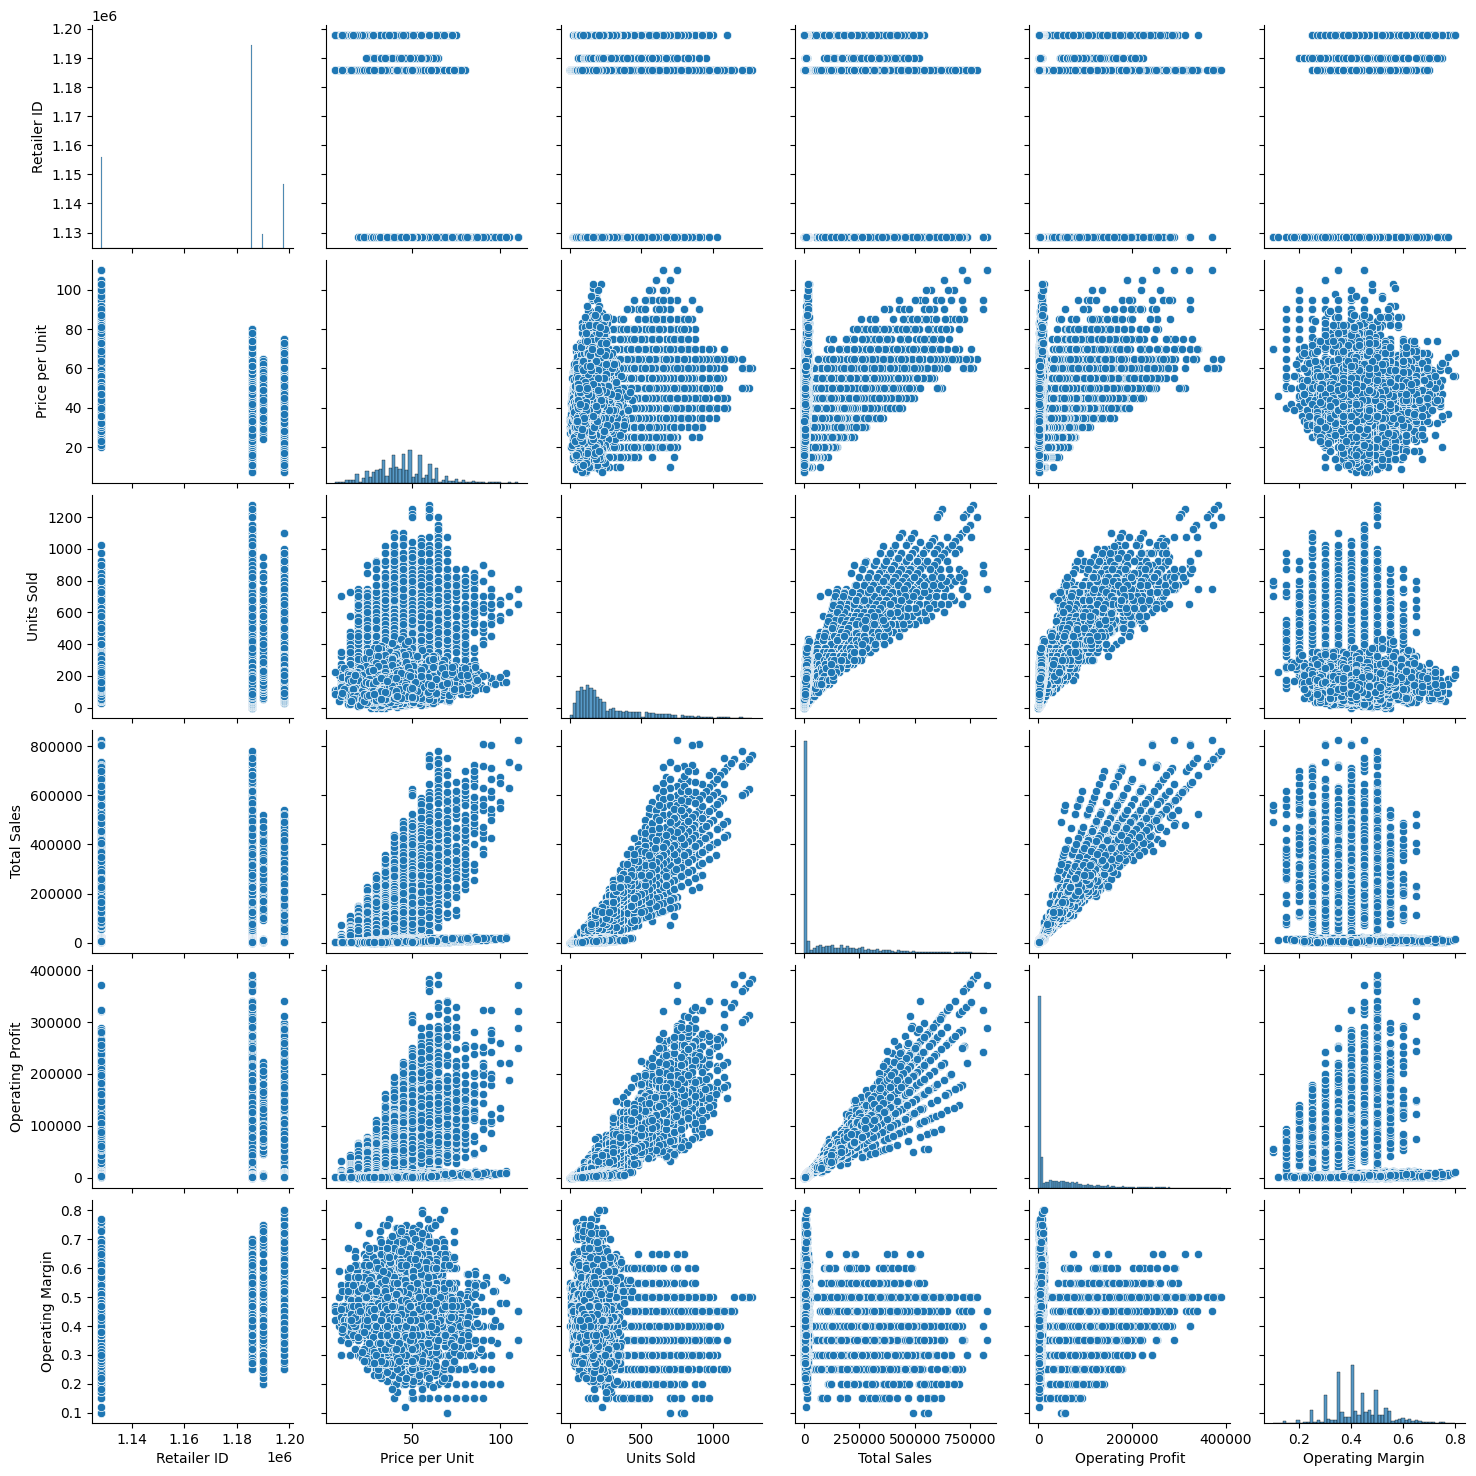

In [6]:
sns.pairplot(df)
# TARGET : Total Sales
# FEATURES : Definir

In [7]:
df["Region"].value_counts()
# Region = pd.DataFrame({"Region":["West","Northeast","Midwest","South","Southeast"]})

Region
West         2448
Northeast    2376
Midwest      1872
South        1728
Southeast    1224
Name: count, dtype: int64

In [8]:
df["State"].value_counts()

State
Texas             432
California        432
New York          360
Florida           360
Pennsylvania      216
Nevada            216
Tennessee         216
Alabama           216
Virginia          216
Utah              216
Oregon            216
Louisiana         216
Idaho             216
Arizona           216
New Mexico        216
Georgia           216
Mississippi       216
Arkansas          216
Oklahoma          216
Connecticut       216
Rhode Island      216
Massachusetts     216
Vermont           216
New Hampshire     216
Illinois          144
Colorado          144
Washington        144
Minnesota         144
Montana           144
Nebraska          144
Maine             144
Alaska            144
Hawaii            144
Wyoming           144
Michigan          144
Missouri          144
South Carolina    144
North Carolina    144
Ohio              144
Kentucky          144
Kansas            144
South Dakota      144
North Dakota      144
Iowa              144
Wisconsin         144
Indi

# **Productos más vendidos**

In [9]:
df["Product"].value_counts()
# Product = pd.DataFrame({"Product":["Men's Street Footwear", "Men's Athletic Footwear","Women's Street Footwear",
# "Women's Apparel","Women's Athletic Footwear","Men's Apparel" ]})
# Genero = pd.DataFrame ({"Men´s": ["Men's Street Footwear", "Men's Athletic Footwear","Men's Apparel"], 
# "Women´s":["Women's Street Footwear","Women's Apparel","Women's Athletic Footwear"]})

Product
Men's Street Footwear        1610
Men's Athletic Footwear      1610
Women's Street Footwear      1608
Women's Apparel              1608
Women's Athletic Footwear    1606
Men's Apparel                1606
Name: count, dtype: int64

In [16]:
df["Product"].unique()

<ArrowStringArray>
[    'Men's Street Footwear',   'Men's Athletic Footwear',
   'Women's Street Footwear', 'Women's Athletic Footwear',
             'Men's Apparel',           'Women's Apparel']
Length: 6, dtype: str

valorar si transforamr estos datos en caracteres numericos para hacer los modelos, y solo estudiar producto de mujeres y hombres

In [10]:
Productos_mas_vendidos = df.groupby('Product')['Total Sales'].sum().sort_values(ascending = False).reset_index()
Productos_mas_vendidos.index+=1 # el índice comienza desde 0 por defecto, así que sumamos 1 al índice aquí
Productos_mas_vendidos

,Product,Total Sales
1,Men's Street Footwear,208826244.0
2,Women's Apparel,179038860.0
3,Men's Athletic Footwear,153673680.0
4,Women's Street Footwear,128002813.0
5,Men's Apparel,123728632.0
6,Women's Athletic Footwear,106631896.0


**Gráfica de los productos más vendidos.**

C:\Users\data_\AppData\Local\Temp\ipykernel_14296\2225386984.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels() , fontsize = 16)


Text(0.5, 1.0, 'Top Selling Products')

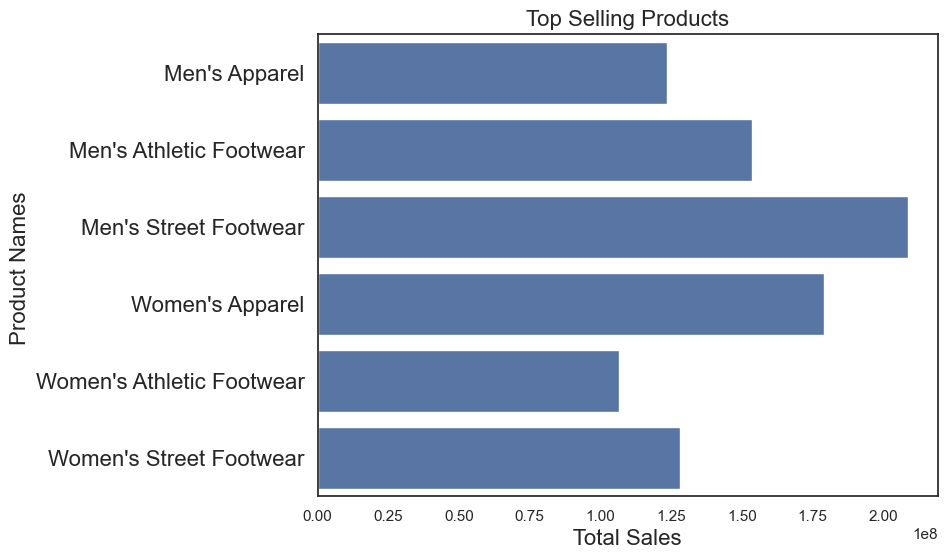

In [20]:

fig , ax = plt.subplots(figsize=(8,6))

sns.barplot(data = Productos_mas_vendidos,y= 'Product',x ='Total Sales')
ax.set_yticklabels(ax.get_yticklabels() , fontsize = 16)

ax.set_xlabel(' Total Sales ', fontsize = 16)
ax.set_ylabel('Product Names ', fontsize = 16)
ax.set_title('Top Selling Products', fontsize = 16)
    

**Mayor Beneficio operativo por ciudad**


In [21]:
df["City"].value_counts()

City
Portland          360
Charleston        288
New York          216
Houston           216
San Francisco     216
Los Angeles       216
Dallas            216
Philadelphia      216
Las Vegas         216
Knoxville         216
Birmingham        216
Orlando           216
Richmond          216
Salt Lake City    216
New Orleans       216
Boise             216
Phoenix           216
Albuquerque       216
Atlanta           216
Jackson           216
Little Rock       216
Oklahoma City     216
Hartford          216
Providence        216
Boston            216
Burlington        216
Manchester        216
Chicago           144
Denver            144
Seattle           144
Miami             144
Minneapolis       144
Billings          144
Omaha             144
Anchorage         144
Honolulu          144
Albany            144
Cheyenne          144
Detroit           144
St. Louis         144
Charlotte         144
Columbus          144
Louisville        144
Wichita           144
Sioux Falls       144
Fargo

In [15]:
df["City"].unique()

<ArrowStringArray>
[      'New York',        'Houston',  'San Francisco',    'Los Angeles',
        'Chicago',         'Dallas',   'Philadelphia',      'Las Vegas',
         'Denver',        'Seattle',          'Miami',    'Minneapolis',
       'Billings',      'Knoxville',          'Omaha',     'Birmingham',
       'Portland',      'Anchorage',       'Honolulu',        'Orlando',
         'Albany',       'Cheyenne',       'Richmond',        'Detroit',
      'St. Louis', 'Salt Lake City',    'New Orleans',          'Boise',
        'Phoenix',    'Albuquerque',        'Atlanta',     'Charleston',
      'Charlotte',       'Columbus',     'Louisville',        'Jackson',
    'Little Rock',  'Oklahoma City',        'Wichita',    'Sioux Falls',
          'Fargo',     'Des Moines',      'Milwaukee',   'Indianapolis',
      'Baltimore',     'Wilmington',         'Newark',       'Hartford',
     'Providence',         'Boston',     'Burlington',     'Manchester']
Length: 52, dtype: str

In [22]:
Mayor_Beneficio = df.groupby('City')['Operating Profit'].sum().sort_values(ascending = False).reset_index().head(10)
Mayor_Beneficio.index+=1
Mayor_Beneficio

,City,Operating Profit
1,Charleston,15607190.11
2,New York,13899973.16
3,Miami,12168619.11
4,Portland,10760799.37
5,San Francisco,10256249.56
6,Houston,9845141.06
7,Charlotte,9756422.87
8,Albany,9429850.91
9,New Orleans,9417233.49
10,Birmingham,9147581.39


**Grafico Mayor Beneficio por ciudad** 

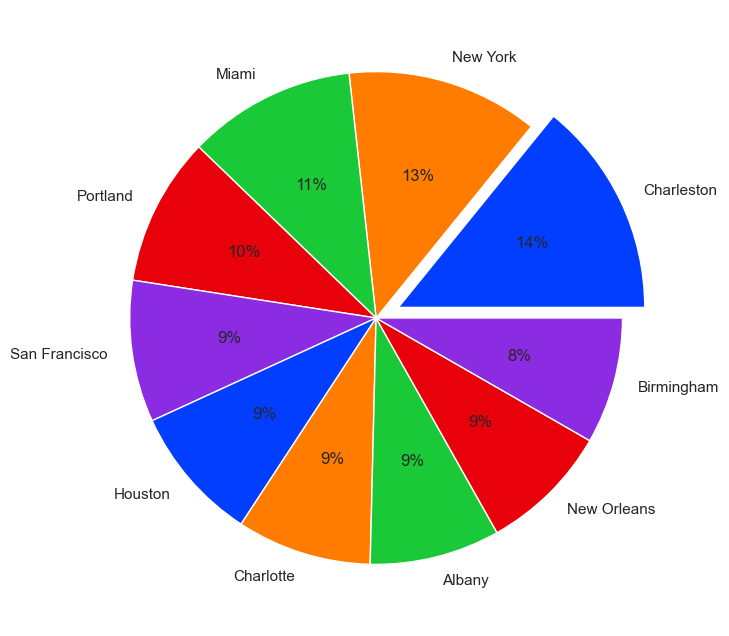

In [23]:
#for pie chart we need 2 lists
data= list(Mayor_Beneficio['Operating Profit']) #convert Operating Profit series in a list
labels = list(Mayor_Beneficio['City']) #convert city series in a list
fig , ax = plt.subplots(figsize=(10,8))

colors = sns.color_palette('bright')[0:5]
plt.pie(data, labels = labels,colors = colors, autopct='%.0f%%', explode = (0.1, 0,0,0,0,0,0,0,0,0))
plt.show()

**Mejor Minorista o Tienda** 

In [25]:
df["Retailer"].value_counts()
#Retailer = pd.DataFrame ({"Retailer": ["Foot Locker", "West Gear","Sports Direct", "Kohl's", "Amazon", "Walmart"]})

Retailer
Foot Locker      2637
West Gear        2374
Sports Direct    2032
Kohl's           1030
Amazon            949
Walmart           626
Name: count, dtype: int64

In [14]:
df["Retailer"].unique()

<ArrowStringArray>
['Foot Locker', 'Walmart', 'Sports Direct', 'West Gear', 'Kohl's', 'Amazon']
Length: 6, dtype: str

In [51]:
Mejor_cliente = df.groupby('Retailer')['Operating Profit'].sum().sort_values(ascending=False).reset_index()
Mejor_cliente.index += 1
Mejor_cliente

,Retailer,Operating Profit
1,West Gear,85667873.18
2,Foot Locker,80722124.81
3,Sports Direct,74332954.96
4,Kohl's,36811252.58
5,Amazon,28818503.31
6,Walmart,25782052.61


**Grafico de barras de los principales minoristas** 

C:\Users\data_\AppData\Local\Temp\ipykernel_7020\2863617178.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= Mejor_cliente, x='Operating Profit', y='Retailer', palette='Blues_r')
C:\Users\data_\AppData\Local\Temp\ipykernel_7020\2863617178.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels() , fontsize = 12)


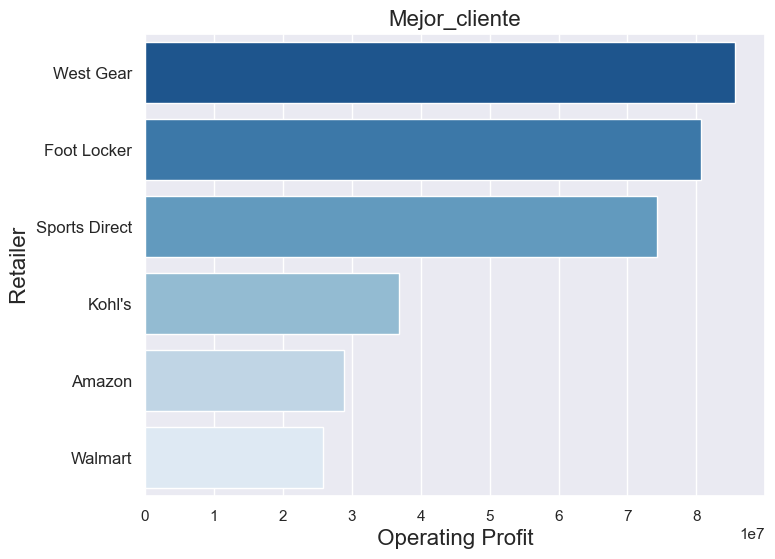

In [52]:
fig , ax = plt.subplots(figsize=(8,6))
sns.set(style='darkgrid')
sns.barplot(data= Mejor_cliente, x='Operating Profit', y='Retailer', palette='Blues_r')
ax.set_yticklabels(ax.get_yticklabels() , fontsize = 12)
ax.set_xlabel(' Operating Profit ', fontsize = 16)
ax.set_ylabel(' Retailer ', fontsize = 16)
ax.set_title('Mejor_cliente', fontsize = 16)
plt.show()

Estudiar un modelo principal minorista

**Mejor metodo de ventas** 

In [ ]:
df["Sales Method"].value_counts()
# Sales Method = pd.DataFrame ({"Sales Method": ["Online", "Outlet","In-Store"]})

Sales Method
Online      4889
Outlet      3019
In-store    1740
Name: count, dtype: int64

In [13]:
df["Sales Method"].unique()

<ArrowStringArray>
['In-store', 'Outlet', 'Online']
Length: 3, dtype: str

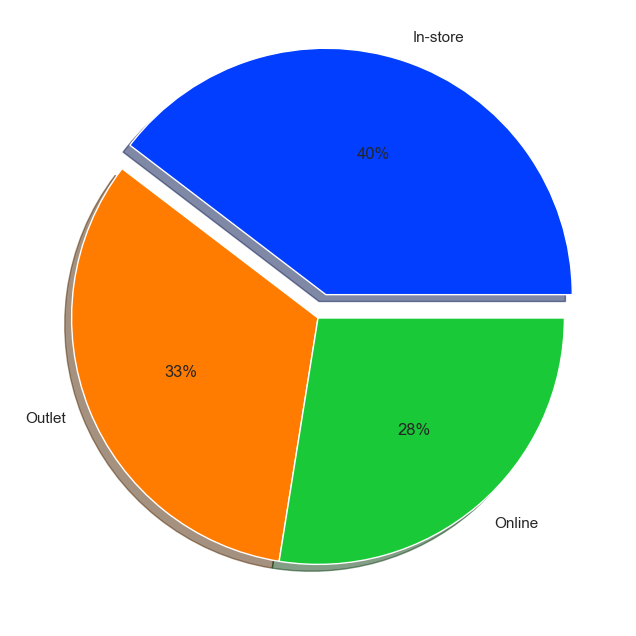

In [21]:
top_methods = df.groupby('Sales Method')['Total Sales'].sum().sort_values(ascending=False).reset_index()
#for pie chart we need 2 lists
data= list(top_methods['Total Sales']) #convert Operating Profit series in a list
labels = list(top_methods['Sales Method'])
fig , ax = plt.subplots(figsize=(10,8))

colors = sns.color_palette('bright')[0:5]
plt.pie(data, labels = labels,colors = colors, autopct='%.0f%%', explode = (0.1, 0,0), shadow =True)
plt.show()

# Correlaccion de variables.
> Target: Ventas

<Axes: >

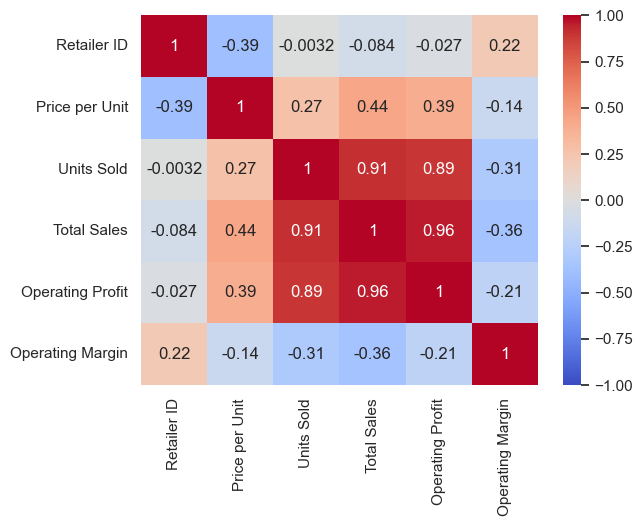

In [29]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",vmin=-1, annot = True)


**Correlación Ventas Totales con Beneficio Operativo = 0,96**  
**Correlación Ventas Totales con Unidades Vendidas = 0,91**  
**Correlación Ventas Totales con Precio por Unidad = 0,44**  
**Esta variables estan fuertemente realcionadas NO VALEN PARA HACER UN MODELO.**  
Porque si las dejo, el modelo simplemente aprenderá a multiplicar Precio×Unidades y te dará un error de 0.00. Si quieres predecir cuánto vas a vender el mes que viene, aún no sabes cuántas unidades vas a vender. Tu modelo debe basarse en el contexto (fecha, lugar, producto, método de venta, precio propuesto).

# **Feature Engineering.**